
                              Week 1 Day 1 :Statistical EDA & Data Spread
                              Uber Data Engineering & Analytics Program
---




🎯 GOAL:Understand how data varies (spread, skew, outliers) & practice basic descriptive statistics.

In [1]:
# Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import pandas as pd
import numpy as np

# Create a mock Uber trips dataset
np.random.seed(42)

# 50 trips: mostly normal fares + few outliers
data = {
    "trip_id": range(1, 51),
    "fare_amount": np.concatenate([
        np.random.normal(250, 50, 45),   # typical fares
        np.random.normal(800, 100, 5)    # a few long expensive trips
    ]),
    "trip_distance_km": np.concatenate([
        np.random.normal(12, 3, 45),
        np.random.normal(35, 5, 5)
    ]),
    "trip_time_min": np.concatenate([
        np.random.normal(25, 5, 45),
        np.random.normal(60, 10, 5)
    ]),
}

df = pd.DataFrame(data)

# Round for readability
df = df.round(2)

df.head()


,trip_id,fare_amount,trip_distance_km,trip_time_min
0,1,274.84,12.97,17.92
1,2,243.09,10.84,22.90
2,3,282.38,9.97,23.29
3,4,326.15,13.84,20.99
4,5,238.29,15.09,24.19


In [3]:
df.describe()


,trip_id,fare_amount,trip_distance_km,trip_time_min
count,50.00000,50.000000,50.000000,50.000000
mean,25.50000,292.183400,14.307200,28.208400
std,14.57738,169.334035,7.132875,11.539068
min,1.00000,152.020000,4.140000,15.410000
25%,13.25000,219.925000,10.625000,21.352500
50%,25.50000,243.655000,12.630000,25.420000
75%,37.75000,281.067500,14.880000,29.042500
max,50.00000,905.710000,36.480000,67.820000


In [4]:
x = np.array([10, 12, 15, 20, 30])  # You can replace with sample values from dataset

mean = x.mean()
variance = np.mean((x - mean)**2)
std_dev = np.sqrt(variance)

print(f"Mean: {mean}")
print(f"Variance: {variance}")
print(f"Standard Deviation: {std_dev}")


Mean: 17.4
Variance: 51.04
Standard Deviation: 7.1442284397967


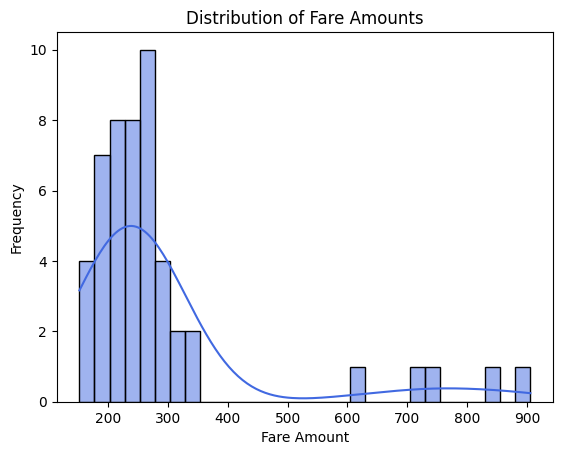

In [5]:
sns.histplot(df['fare_amount'], bins=30, kde=True, color='royalblue')
plt.title("Distribution of Fare Amounts")
plt.xlabel("Fare Amount")
plt.ylabel("Frequency")
plt.show()


In [6]:
# ===============================
# Detecting Skewness Automatically
# ===============================

col = "fare_amount"  # change this to analyze another numeric column

mean_val = df[col].mean()
median_val = df[col].median()
skew_val = df[col].skew()  # pandas skewness measure

print(f"Column: {col}")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Skewness: {skew_val:.3f}")

# Interpretation based on skew value
if skew_val > 0.5:
    skew_type = "Right-skewed (Positive skew)"
    explanation = (
        "The distribution has a long right tail — a few high-value trips "
        "pull the mean higher than the median. Example: long-distance or surge trips."
    )
elif skew_val < -0.5:
    skew_type = "Left-skewed (Negative skew)"
    explanation = (
        "The distribution has a long left tail — some low-value trips pull "
        "the mean lower than the median. Example: short or discounted trips."
    )
else:
    skew_type = "Approximately symmetric (Normal-like)"
    explanation = (
        "The mean and median are close, indicating a balanced spread of fares "
        "around the center."
    )

print("\n📊 Skewness Type:", skew_type)
print("🧠 Interpretation:", explanation)


Column: fare_amount
Mean: 292.18
Median: 243.66
Skewness: 2.570

📊 Skewness Type: Right-skewed (Positive skew)
🧠 Interpretation: The distribution has a long right tail — a few high-value trips pull the mean higher than the median. Example: long-distance or surge trips.
